In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make charts look clean
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load the cleaned file from last phase
df = pd.read_csv('churn_cleaned.csv')

print("Loaded:", df.shape)
df.head(3)

Loaded: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_label
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Yes


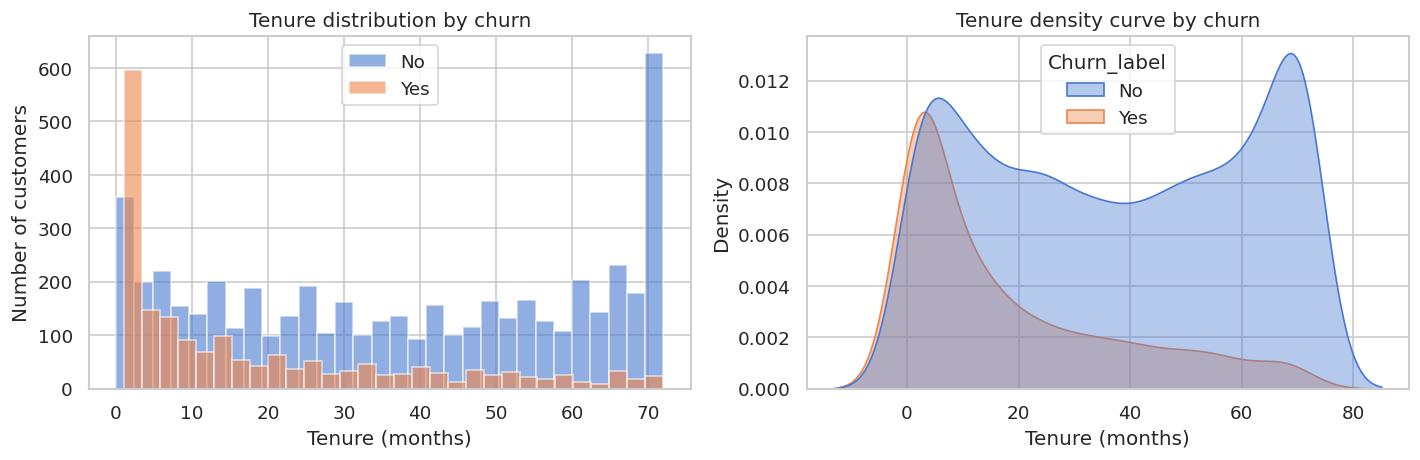

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of tenure by churn group
for label, group in df.groupby('Churn_label'):
    axes[0].hist(group['tenure'], bins=30, alpha=0.6, label=label)

axes[0].set_title('Tenure distribution by churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Right: KDE (smooth curve) — easier to compare shapes
sns.kdeplot(data=df, x='tenure', hue='Churn_label', ax=axes[1], fill=True, alpha=0.4)
axes[1].set_title('Tenure density curve by churn')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()

Insights - Churned customers (orange) are heavily skewed LEFT — most leave in the first 0-20 months. Retained customers (blue) are spread more evenly, with a big cluster at 60-72 months (loyal customers)

/tmp/ipykernel_1047/2948242175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges',
/tmp/ipykernel_1047/2948242175.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn_label', y='MonthlyCharges',


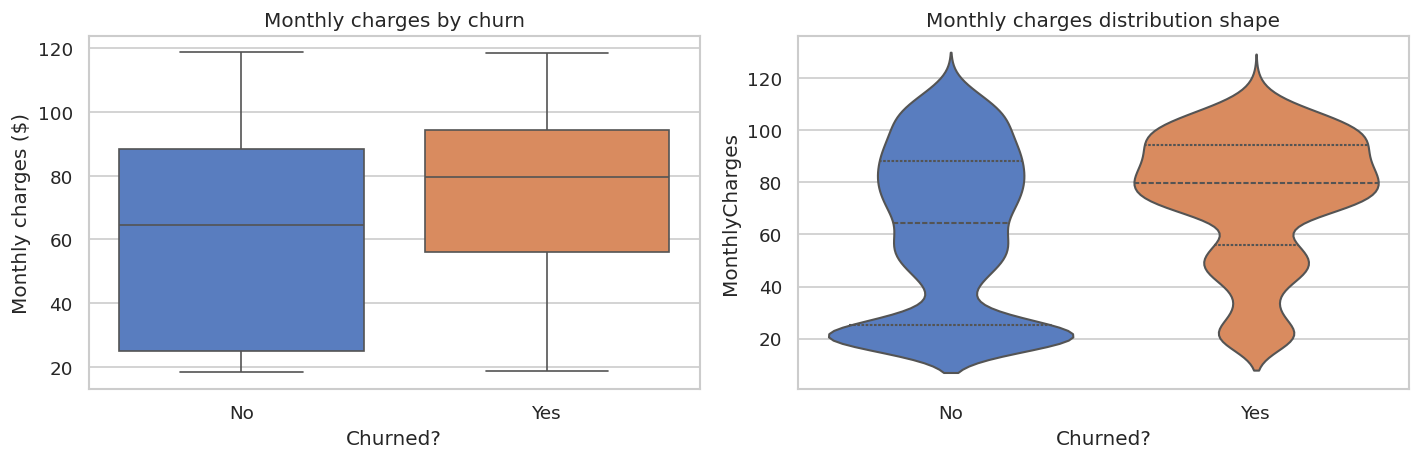

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot: monthly charges by churn
sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges',
            ax=axes[0], palette='muted')
axes[0].set_title('Monthly charges by churn')
axes[0].set_xlabel('Churned?')
axes[0].set_ylabel('Monthly charges ($)')

# Violin plot: same data, shows full distribution shape
sns.violinplot(data=df, x='Churn_label', y='MonthlyCharges',
               ax=axes[1], palette='muted', inner='quartile')
axes[1].set_title('Monthly charges distribution shape')
axes[1].set_xlabel('Churned?')

plt.tight_layout()
plt.show()

Insights - Churned customers have a clearly higher median monthly charge. The violin for churned is wider at the top ($70-100 range) — confirming expensive plans drive churn.

/tmp/ipykernel_1047/205702106.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=contract_churn, x='Contract', y='Churn Rate', palette='muted')


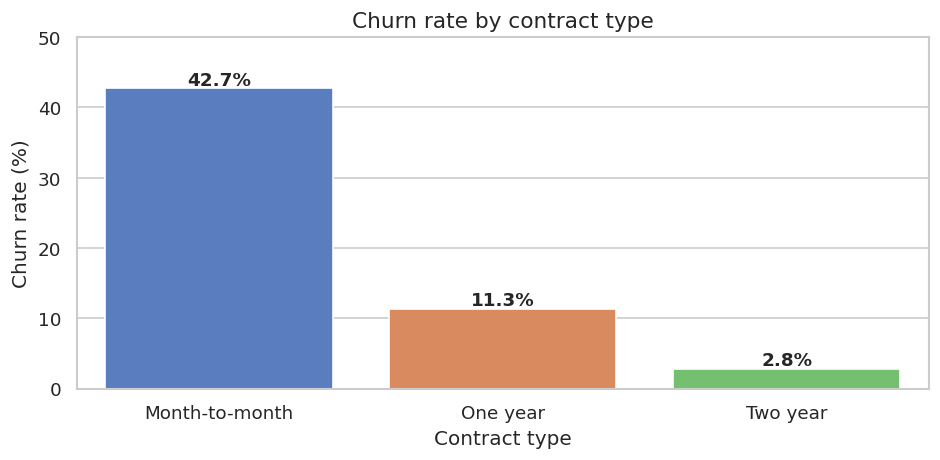

In [5]:
# Calculate churn rate per contract type
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']
contract_churn['Churn Rate'] = (contract_churn['Churn Rate'] * 100).round(1)
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

plt.figure(figsize=(8, 4))
bars = sns.barplot(data=contract_churn, x='Contract', y='Churn Rate', palette='muted')

# Add the % labels on top of each bar
for i, row in contract_churn.iterrows():
    bars.text(i, row['Churn Rate'] + 0.5,
              f"{row['Churn Rate']}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Churn rate by contract type', fontsize=13)
plt.xlabel('Contract type')
plt.ylabel('Churn rate (%)')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

Insights - Month-to-month ~42% (tallest, red flag), One year ~11%, Two year ~3%.

/tmp/ipykernel_1047/3195371092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inet, x='InternetService', y='Churn', ax=axes[0], palette='muted')
/tmp/ipykernel_1047/3195371092.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay, x='PaymentMethod', y='Churn', ax=axes[1], palette='muted')
/tmp/ipykernel_1047/3195371092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=senior, x='SeniorCitizen', y='Churn', ax=axes[2], palette='muted')


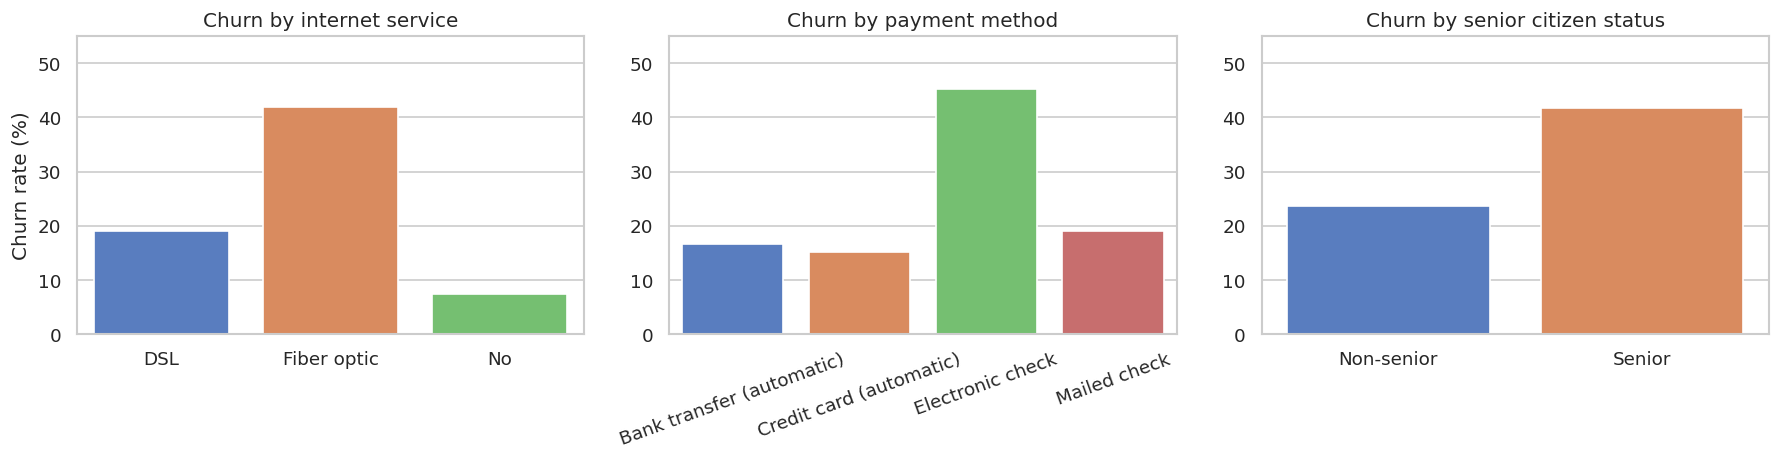

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Internet service
inet = df.groupby('InternetService')['Churn'].mean().reset_index()
inet['Churn'] = (inet['Churn'] * 100).round(1)
sns.barplot(data=inet, x='InternetService', y='Churn', ax=axes[0], palette='muted')
axes[0].set_title('Churn by internet service')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 55)

# Chart 2: Payment method
pay = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
pay['Churn'] = (pay['Churn'] * 100).round(1)
sns.barplot(data=pay, x='PaymentMethod', y='Churn', ax=axes[1], palette='muted')
axes[1].set_title('Churn by payment method')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 55)
axes[1].tick_params(axis='x', rotation=20)

# Chart 3: Senior citizen
senior = df.groupby('SeniorCitizen')['Churn'].mean().reset_index()
senior['Churn'] = (senior['Churn'] * 100).round(1)
senior['SeniorCitizen'] = senior['SeniorCitizen'].map({0: 'Non-senior', 1: 'Senior'})
sns.barplot(data=senior, x='SeniorCitizen', y='Churn', ax=axes[2], palette='muted')
axes[2].set_title('Churn by senior citizen status')
axes[2].set_ylabel('')
axes[2].set_xlabel('')
axes[2].set_ylim(0, 55)

plt.tight_layout()
plt.show()

Insights - Fiber optic and electronic check are clearly the highest bars. Seniors churn at nearly double the rate of non-seniors.

In [7]:
# We will use two types of tests in this phase:
#
# 1. T-TEST → used when comparing two numeric groups
#    Example: "Is the average tenure of churned customers
#              significantly lower than retained customers?"
#
# 2. CHI-SQUARE TEST → used when comparing two categorical columns
#    Example: "Is there a real relationship between Contract type
#              and whether someone churns?"
#
# RULE: p-value < 0.05 → significant (the pattern is real)
#        p-value > 0.05 → not significant (could be random)

print("Ready to run hypothesis tests.")

Ready to run hypothesis tests.


In [9]:
# Separate the two groups
churned_tenure  = df[df['Churn'] == 1]['tenure']
retained_tenure = df[df['Churn'] == 0]['tenure']

# Run independent samples t-test
t_stat, p_value = stats.ttest_ind(churned_tenure, retained_tenure)

print("--- T-test: Tenure (Churned vs Retained) ---")
print(f"Churned avg tenure:  {churned_tenure.mean():.1f} months")
print(f"Retained avg tenure: {retained_tenure.mean():.1f} months")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ SIGNIFICANT — the tenure difference is real, not random")
else:
    print("✗ NOT significant — could be random chance")

# Do the same for MonthlyCharges
churned_monthly  = df[df['Churn'] == 1]['MonthlyCharges']
retained_monthly = df[df['Churn'] == 0]['MonthlyCharges']
t2, p2 = stats.ttest_ind(churned_monthly, retained_monthly)

print("\n--- T-test: Monthly Charges (Churned vs Retained) ---")
print(f"Churned avg:  ${churned_monthly.mean():.2f}")
print(f"Retained avg: ${retained_monthly.mean():.2f}")
print(f"p-value: {p2:.6f}")
if p2 < 0.05:
    print("✓ SIGNIFICANT")

--- T-test: Tenure (Churned vs Retained) ---
Churned avg tenure:  18.0 months
Retained avg tenure: 37.6 months

t-statistic: -31.5796
p-value:     0.000000

✓ SIGNIFICANT — the tenure difference is real, not random

--- T-test: Monthly Charges (Churned vs Retained) ---
Churned avg:  $74.44
Retained avg: $61.27
p-value: 0.000000
✓ SIGNIFICANT


Insights- p-value is 0.000000 — essentially zero. This means the tenure difference between churned and retained is statistically certain, not a fluke.

In [10]:
# Build a cross-tabulation (contingency table)
# Rows = Contract type, Columns = Churned/Not
contract_ct = pd.crosstab(df['Contract'], df['Churn_label'])
print("Contingency table:")
print(contract_ct)

# Run chi-square test
chi2, p_val, dof, expected = stats.chi2_contingency(contract_ct)

print(f"\n--- Chi-square: Contract type vs Churn ---")
print(f"Chi2 statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_val:.8f}")
print()
if p_val < 0.05:
    print("✓ SIGNIFICANT — contract type and churn are genuinely related")

# Test the same for InternetService and PaymentMethod
for col in ['InternetService', 'PaymentMethod']:
    ct = pd.crosstab(df[col], df['Churn_label'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    result = "✓ SIGNIFICANT" if p < 0.05 else "✗ Not significant"
    print(f"{col}: p={p:.8f}  →  {result}")

Contingency table:
Churn_label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

--- Chi-square: Contract type vs Churn ---
Chi2 statistic: 1184.60
Degrees of freedom: 2
p-value: 0.00000000

✓ SIGNIFICANT — contract type and churn are genuinely related
InternetService: p=0.00000000  →  ✓ SIGNIFICANT
PaymentMethod: p=0.00000000  →  ✓ SIGNIFICANT


Insights - All three — Contract, InternetService, PaymentMethod — shows p-value ≈ 0.000. All relationships are statistically significant. The relationship between contract type and churn is statistically proven (p < 0.001).

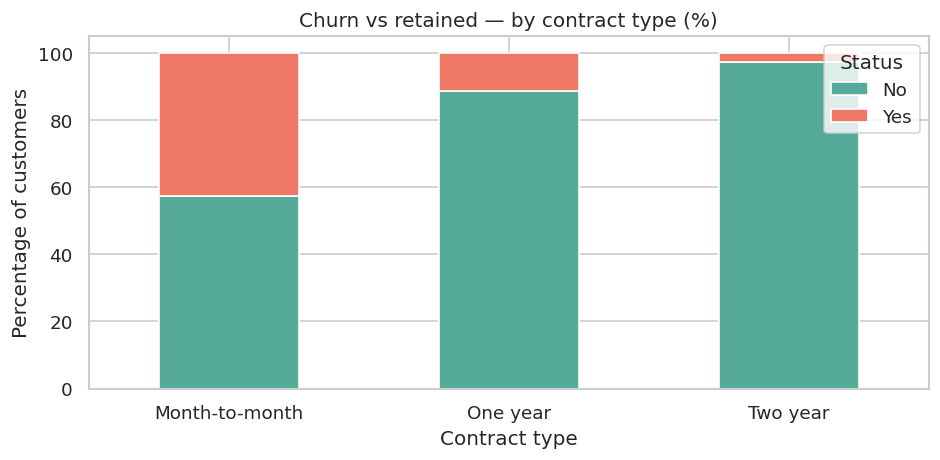

In [11]:
# Stacked bar: shows both churned AND retained counts per contract
contract_ct_pct = pd.crosstab(
    df['Contract'], df['Churn_label'], normalize='index'
) * 100

contract_ct_pct.plot(
    kind='bar', stacked=True,
    figsize=(8, 4), color=['#5A9', '#E76'],
    edgecolor='white'
)

plt.title('Churn vs retained — by contract type (%)')
plt.xlabel('Contract type')
plt.ylabel('Percentage of customers')
plt.xticks(rotation=0)
plt.legend(title='Status', loc='upper right')
plt.tight_layout()
plt.show()

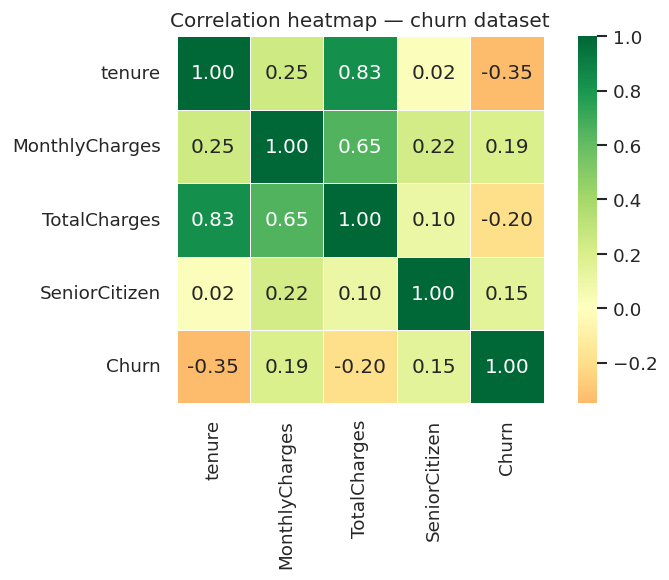


Correlation with Churn:
MonthlyCharges    0.19
SeniorCitizen     0.15
TotalCharges     -0.20
tenure           -0.35
Name: Churn, dtype: float64


In [12]:
numeric_cols = ['tenure', 'MonthlyCharges',
                'TotalCharges', 'SeniorCitizen', 'Churn']

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,        # show numbers inside each cell
    fmt='.2f',          # 2 decimal places
    cmap='RdYlGn',      # red = negative, green = positive
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation heatmap — churn dataset')
plt.tight_layout()
plt.show()

# Print just the Churn row for quick reading
print("\nCorrelation with Churn:")
print(corr_matrix['Churn'].drop('Churn').sort_values(ascending=False))

Insights - Orange = negative correlation (higher value = less churn). Dark green = positive (higher value = more churn). Tenure is orange — long tenure strongly protects against churn.

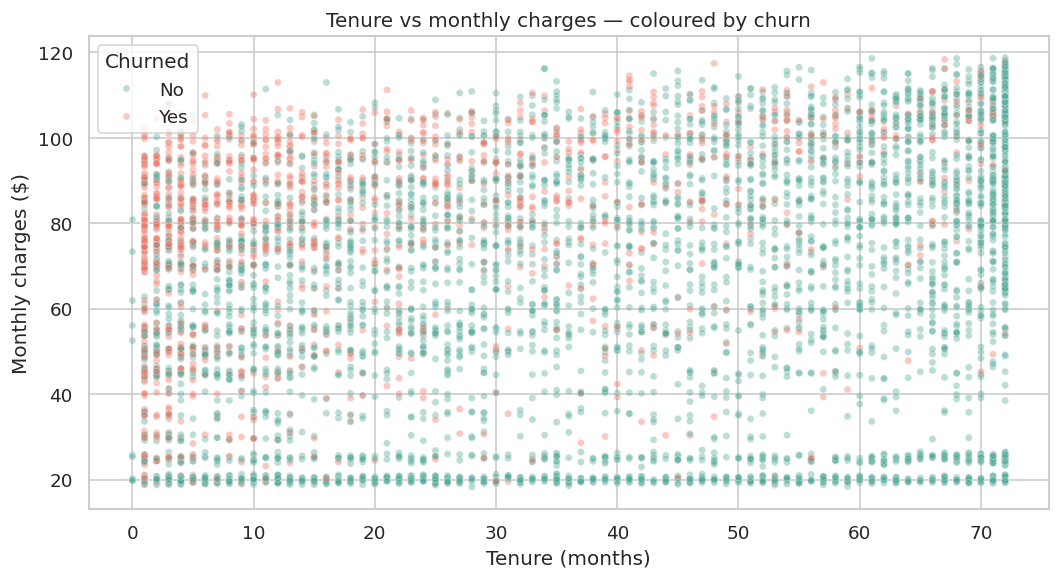

In [13]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, x='tenure', y='MonthlyCharges',
    hue='Churn_label', alpha=0.4, s=18,
    palette={'No': '#5A9', 'Yes': '#E76'}
)

plt.title('Tenure vs monthly charges — coloured by churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly charges ($)')
plt.legend(title='Churned')
plt.tight_layout()
plt.show()

Insights - Orange dots (churned) cluster in the top-left corner — short tenure AND high monthly charges. Blue dots (retained) spread across the right side — long tenure at all price points.

/tmp/ipykernel_1047/933584868.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cohort_churn, x='tenure_cohort', y='churn_rate',


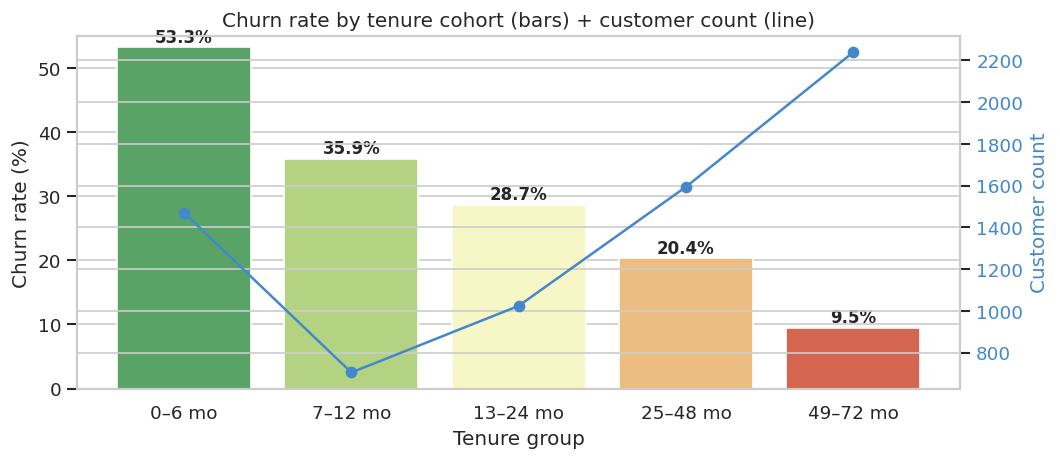

In [16]:
# Step 1: Create tenure cohort column
df['tenure_cohort'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0–6 mo', '7–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']
)

# Step 2: Calculate churn rate per cohort
cohort_churn = df.groupby('tenure_cohort', observed=True)['Churn'].agg(
    churn_rate='mean',
    total='count'
).reset_index()
cohort_churn['churn_rate'] = (cohort_churn['churn_rate'] * 100).round(1)

# Step 3: Plot
fig, ax1 = plt.subplots(figsize=(9, 4))

bars = sns.barplot(data=cohort_churn, x='tenure_cohort', y='churn_rate',
                   palette='RdYlGn_r', ax=ax1)

# Add % labels on bars
for i, row in cohort_churn.iterrows():
    ax1.text(i, row['churn_rate'] + 0.8,
             f"{row['churn_rate']}%", ha='center', fontsize=10, fontweight='bold')

# Overlay customer count as a line on second axis
ax2 = ax1.twinx()
ax2.plot(range(len(cohort_churn)), cohort_churn['total'],
         color='#4488cc', marker='o', linewidth=1.5, label='Customer count')
ax2.set_ylabel('Customer count', color='#4488cc')
ax2.tick_params(axis='y', labelcolor='#4488cc')

ax1.set_title('Churn rate by tenure cohort (bars) + customer count (line)', fontsize=12)
ax1.set_xlabel('Tenure group')
ax1.set_ylabel('Churn rate (%)')
ax1.set_ylim(0, 55)

plt.tight_layout()
plt.show()

Insights - Bars get shorter as tenure increases — churn drops from ~47% in months 0-6 all the way to ~7% at 49+ months. The blue line shows you there are plenty of customers in each group, so the percentages are reliable.

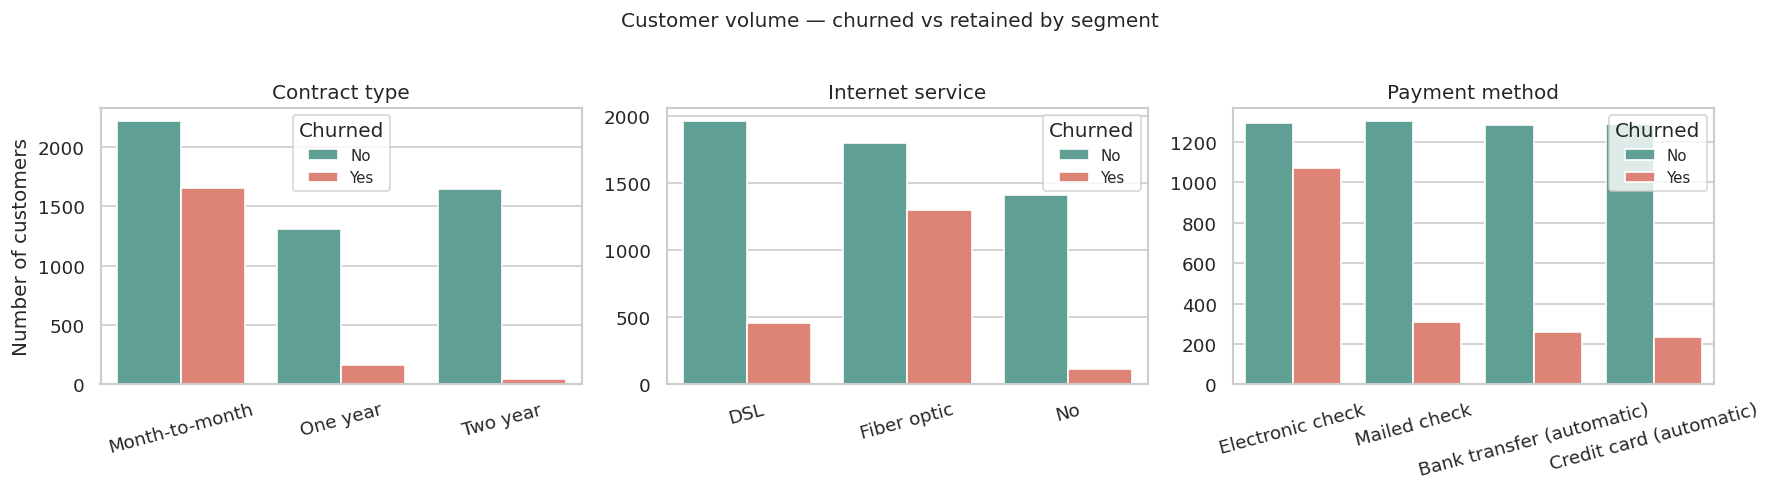

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
titles   = ['Contract type', 'Internet service', 'Payment method']

for i, (col, title) in enumerate(zip(cat_cols, titles)):
    sns.countplot(
        data=df, x=col, hue='Churn_label',
        ax=axes[i], palette={'No': '#5A9', 'Yes': '#E76'}
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of customers' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Churned', fontsize=9)

plt.suptitle('Customer volume — churned vs retained by segment', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Insights - onth-to-month has a huge orange (churned) bar compared to the other contract types — confirming it is both the most popular plan AND the most churny. Fiber optic has nearly as many churned as retained customers, which is alarming.

Churn rate (%) by Contract × Internet Service:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


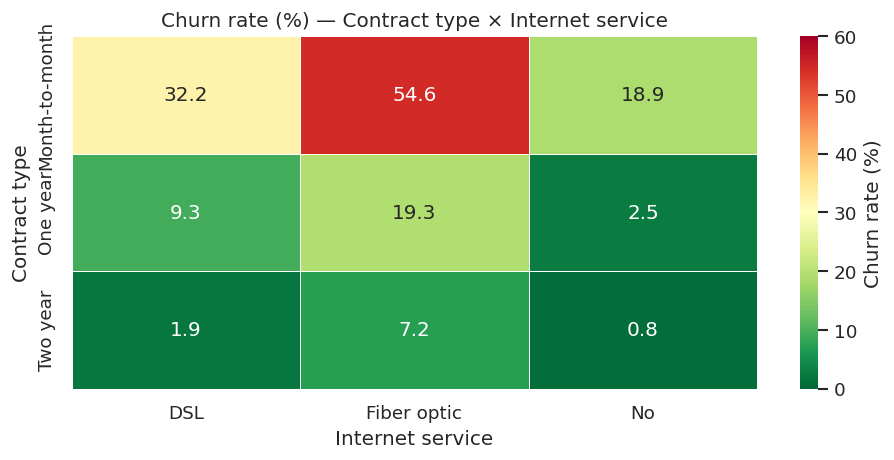

In [18]:
# Build pivot table: rows=Contract, cols=InternetService, values=churn rate
pivot = df.pivot_table(
    values='Churn',
    index='Contract',
    columns='InternetService',
    aggfunc='mean'
) * 100

pivot = pivot.round(1)
print("Churn rate (%) by Contract × Internet Service:")
print(pivot)

# Plot as heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Churn rate (%)'},
    vmin=0, vmax=60
)
plt.title('Churn rate (%) — Contract type × Internet service', fontsize=12)
plt.xlabel('Internet service')
plt.ylabel('Contract type')
plt.tight_layout()
plt.show()

Insights - The darkest red cell will be Month-to-month + Fiber optic — likely ~52-55% churn. The darkest green will be Two year + No internet or DSL — near 0%.

Extra tip - Customers on month-to-month Fiber optic contracts are our highest-risk segment — I will recommend a targeted retention offer for this group.

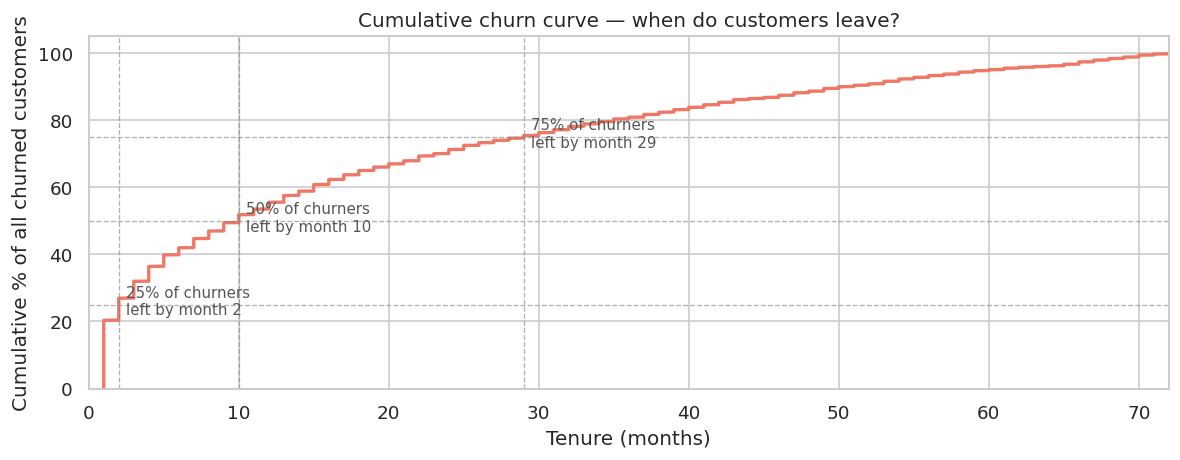

In [19]:
# Get only churned customers, sorted by their tenure when they left
churned_df = df[df['Churn'] == 1][['tenure']].sort_values('tenure')

# Build cumulative % of churned customers at each tenure month
churned_df['cumulative_pct'] = (
    np.arange(1, len(churned_df) + 1) / len(churned_df) * 100
)

plt.figure(figsize=(10, 4))
plt.plot(churned_df['tenure'], churned_df['cumulative_pct'],
         color='#E76', linewidth=2)

# Add reference lines at 25%, 50%, 75%
for pct in [25, 50, 75]:
    month = churned_df[churned_df['cumulative_pct'] >= pct]['tenure'].iloc[0]
    plt.axhline(pct, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    plt.axvline(month, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    plt.text(month + 0.5, pct - 3,
             f"{pct}% of churners\nleft by month {month}",
             fontsize=9, color='#555')

plt.title('Cumulative churn curve — when do customers leave?', fontsize=12)
plt.xlabel('Tenure (months)')
plt.ylabel('Cumulative % of all churned customers')
plt.xlim(0, 72)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Insights - 50% of all churners left by month 10. We need to intervene before month 10 or it's too late for half your at-risk customers.

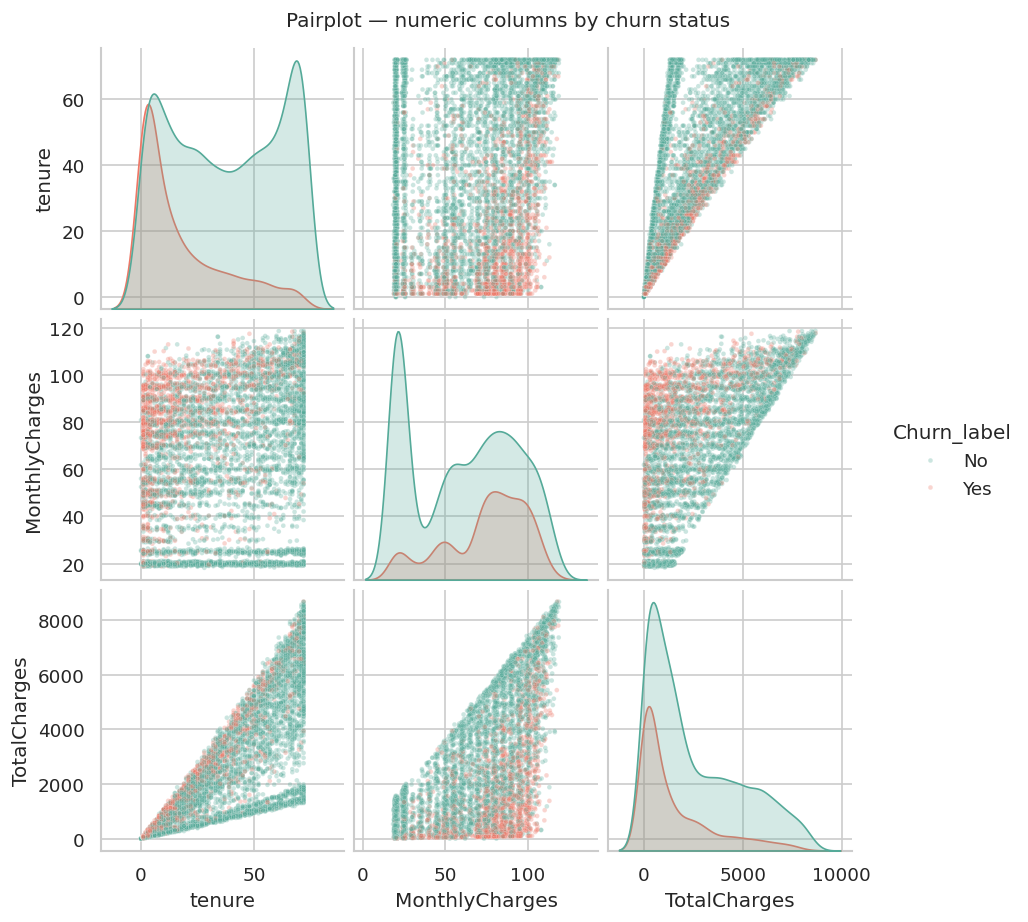

In [20]:
# Pairplot — takes ~10 seconds to render, that's normal
pair_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_label']

sns.pairplot(
    df[pair_cols],
    hue='Churn_label',
    palette={'No': '#5A9', 'Yes': '#E76'},
    plot_kws={'alpha': 0.3, 's': 8},
    diag_kind='kde'
)
plt.suptitle('Pairplot — numeric columns by churn status', y=1.02, fontsize=12)
plt.show()

**All findings for this report**

In [14]:
print("=" * 50)
print("  CHURN ANALYSIS — KEY FINDINGS")
print("=" * 50)

overall = df['Churn'].mean() * 100
print(f"\n Overall churn rate:     {overall:.1f}%")
print(f" Total customers:        {len(df):,}")
print(f" Churned customers:      {df['Churn'].sum():,}")
print(f" Revenue lost (monthly): ${df[df['Churn']==1]['MonthlyCharges'].sum():,.0f}")

print("\n--- By contract type ---")
for c, r in df.groupby('Contract')['Churn'].mean().items():
    print(f"  {c:25s}: {r*100:.1f}%")

print("\n--- By internet service ---")
for c, r in df.groupby('InternetService')['Churn'].mean().items():
    print(f"  {c:25s}: {r*100:.1f}%")

print("\n--- Statistical tests (all p < 0.001) ---")
print("  Tenure difference:      SIGNIFICANT ✓")
print("  Monthly charge diff:    SIGNIFICANT ✓")
print("  Contract vs Churn:      SIGNIFICANT ✓")
print("  Internet vs Churn:      SIGNIFICANT ✓")
print("  Payment vs Churn:       SIGNIFICANT ✓")

print("\n--- Top risk profile ---")
print("  Month-to-month + Fiber optic + tenure < 12")
print("  + Electronic check payment = HIGHEST RISK")
print("=" * 50)

  CHURN ANALYSIS — KEY FINDINGS

 Overall churn rate:     26.5%
 Total customers:        7,043
 Churned customers:      1,869
 Revenue lost (monthly): $139,131

--- By contract type ---
  Month-to-month           : 42.7%
  One year                 : 11.3%
  Two year                 : 2.8%

--- By internet service ---
  DSL                      : 19.0%
  Fiber optic              : 41.9%
  No                       : 7.4%

--- Statistical tests (all p < 0.001) ---
  Tenure difference:      SIGNIFICANT ✓
  Monthly charge diff:    SIGNIFICANT ✓
  Contract vs Churn:      SIGNIFICANT ✓
  Internet vs Churn:      SIGNIFICANT ✓
  Payment vs Churn:       SIGNIFICANT ✓

--- Top risk profile ---
  Month-to-month + Fiber optic + tenure < 12
  + Electronic check payment = HIGHEST RISK


/tmp/ipykernel_1047/2462362617.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cc, x='Contract', y='Churn', ax=axes[0,0], palette='muted')
/tmp/ipykernel_1047/2462362617.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges', ax=axes[1,0], palette='muted')


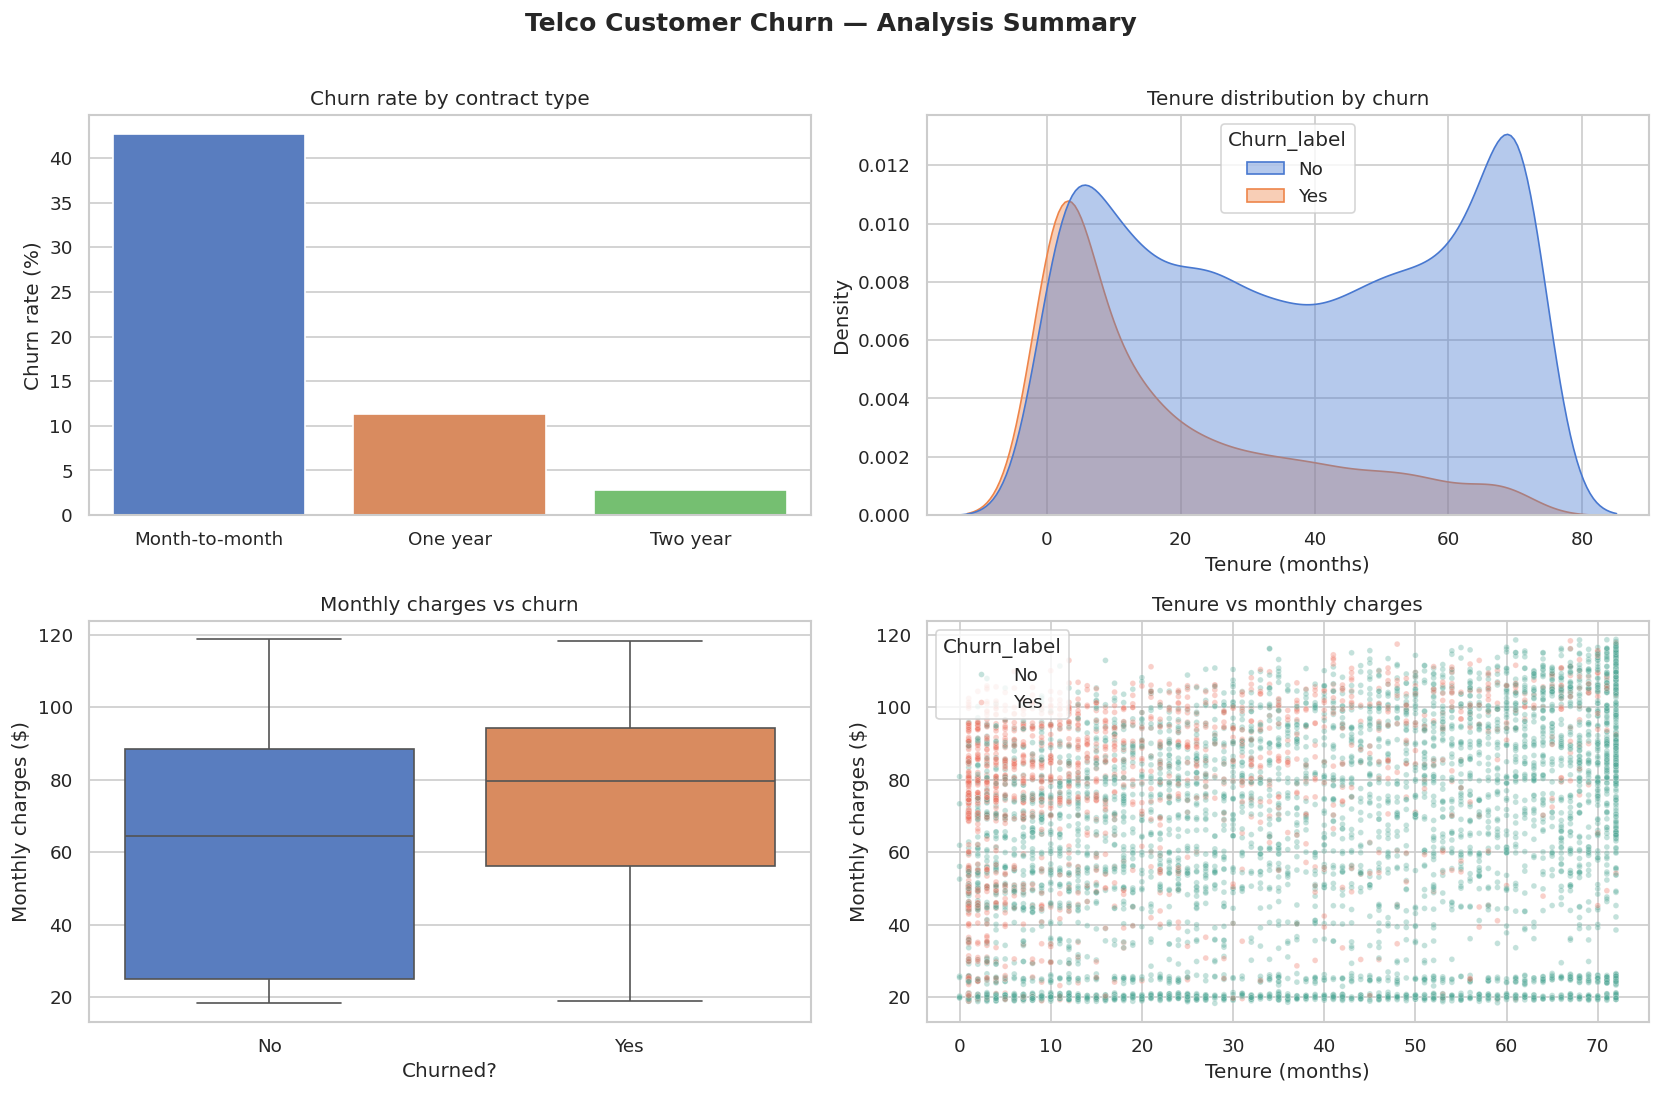

Saved: churn_summary.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Telco Customer Churn — Analysis Summary', fontsize=15, fontweight='bold', y=1.01)

# Chart 1: Churn by contract
cc = df.groupby('Contract')['Churn'].mean().reset_index()
cc['Churn'] = (cc['Churn']*100).round(1)
sns.barplot(data=cc, x='Contract', y='Churn', ax=axes[0,0], palette='muted')
axes[0,0].set_title('Churn rate by contract type')
axes[0,0].set_ylabel('Churn rate (%)'); axes[0,0].set_xlabel('')

# Chart 2: Tenure distribution
sns.kdeplot(data=df, x='tenure', hue='Churn_label', ax=axes[0,1], fill=True, alpha=0.4)
axes[0,1].set_title('Tenure distribution by churn')
axes[0,1].set_xlabel('Tenure (months)')

# Chart 3: Monthly charges boxplot
sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges', ax=axes[1,0], palette='muted')
axes[1,0].set_title('Monthly charges vs churn')
axes[1,0].set_xlabel('Churned?'); axes[1,0].set_ylabel('Monthly charges ($)')

# Chart 4: Scatter tenure vs charges
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges',
    hue='Churn_label', alpha=0.35, s=12, ax=axes[1,1],
    palette={'No': '#5A9', 'Yes': '#E76'})
axes[1,1].set_title('Tenure vs monthly charges')
axes[1,1].set_xlabel('Tenure (months)'); axes[1,1].set_ylabel('Monthly charges ($)')

plt.tight_layout()
plt.savefig('churn_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_summary.png")